In [10]:
import os, sys
if "google.colab" in sys.modules:
    if not os.path.exists("/content/NLP_and_Language_technologies-Group-9"):
        !git clone https://github.com/Samkwizera/NLP_and_Language_technologies-Group-9.git /content/NLP_and_Language_technologies-Group-9
    %cd /content/NLP_and_Language_technologies-Group-9
    !pip install -q -r requirements.txt
    # csvs aren't in git, so copy them from drive (MyDrive/nlp_data/)
    from google.colab import drive
    drive.mount("/content/drive")
    import glob, shutil
    # zindi downloads come as "train (1).csv" etc, the code expects Train.csv / Test.csv
    for f in glob.glob("/content/drive/MyDrive/nlp_data/*.csv"):
        name = os.path.basename(f).lower()
        if name.startswith("train"):
            shutil.copy(f, "data/Train.csv")
        elif name.startswith("test"):
            shutil.copy(f, "data/Test.csv")
    if not os.path.exists("data/Train.csv"):
        raise FileNotFoundError("put the train/test csvs in MyDrive/nlp_data/")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
os.listdir("data")

/content/NLP_and_Language_technologies-Group-9
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['README.md', 'Test.csv', 'Train.csv']

In [11]:
from src.split import load_split
from src.utils import ensure_dirs

ensure_dirs()
train_df, val_df, test_df = load_split()
len(train_df), len(val_df), len(test_df)

(6995, 1502, 1503)

In [12]:
from src.models.transformer import run_experiment

trainer, tokenizer, metrics = run_experiment(
    exp_id="T1",
    train_df=train_df,
    eval_df=val_df,
    model_key="twitter-roberta",
    epochs=3,
    batch_size=16,
    lr=2e-5,
    change="baseline fine-tune, no changes",
    reason="cardiffnlp/twitter-roberta-base is pretrained on tweets, so it should need little adaptation to our vaccine-tweet domain",
)
metrics

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Rmse,F1 Negative,F1 Neutral,F1 Positive
1,0.535568,0.542989,0.694700,0.796900,0.577000,0.438400,0.844400,0.801300
2,0.459970,0.546575,0.745700,0.810900,0.568200,0.570300,0.848100,0.818600
3,0.302742,0.633436,0.741000,0.802900,0.577000,0.571400,0.841400,0.810300


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy,Rmse,F1 Negative,F1 Neutral,F1 Positive
0.302742,0.633436,3,0.741000,0.802900,0.577000,0.571400,0.841400,0.810300


{'macro_f1': 0.741, 'accuracy': 0.8029, 'rmse': 0.577}

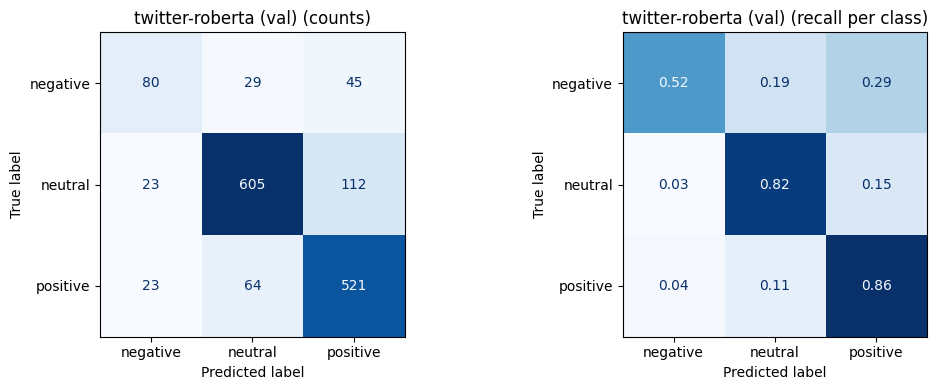

,tweet_id,text,true,predicted,agreement,confidence
416,2LNRNW99,<user> no immunity? No schools other than hon...,1,0,0.666667,0.9961
750,8TLK42RE,The # of people opting out of vaccines has ste...,-1,1,1.000000,0.9953
274,8ELO5X9S,People who don't immunize their children are i...,0,1,0.666667,0.9951
608,DVMK1WEI,"""<user> RT <user> RT <user> For God's sake. Va...",-1,1,0.666667,0.9949
661,WFTO3JZJ,The person who visited Super Bowl village with...,-1,0,0.333333,0.9947
...,...,...,...,...,...,...
397,HGBCEU1V,Common Canine Virus May Lead to New Vaccines f...,1,0,0.666667,0.3808
936,5B6JMNT0,<user> ...pertussis until the third or fourth ...,1,0,1.000000,0.3765
569,NIFW1RDZ,Why does every article about #vaccinations hav...,-1,0,0.666667,0.3741
1235,HD8D4JOD,"<user> <user> She has a Son with Autism, when ...",-1,1,0.666667,0.3620


In [13]:
from src.models.transformer import predict
from src.evaluate import plot_confusion_matrix, export_errors

y_pred, confidence = predict(trainer, tokenizer, val_df)
plot_confusion_matrix(val_df["label"], y_pred, "twitter-roberta (val)", name="transformer_twitterroberta_val_cm")
export_errors(val_df, y_pred, confidence, exp_id="T1")

In [14]:
from src.models.transformer import run_experiment

trainer2, tokenizer2, metrics2 = run_experiment(
    exp_id="T2",
    train_df=train_df,
    eval_df=val_df,
    model_key="afroxlmr",  # or "xlm-r"
    epochs=3,
    batch_size=16,
    lr=2e-5,
    change="multilingual transformer, no changes",
    reason="AfroXLMR is pretrained on African languages including Swahili, so it may handle code-switched or non-English tweets better than a tweet-only English model",
)
metrics2

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Rmse,F1 Negative,F1 Neutral,F1 Positive
1,0.627751,0.601952,0.599500,0.753000,0.690400,0.225800,0.824700,0.748200
2,0.537735,0.569523,0.703400,0.785000,0.644000,0.484600,0.841300,0.784200
3,0.437649,0.585665,0.700800,0.783000,0.650200,0.480600,0.840100,0.781600


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy,Rmse,F1 Negative,F1 Neutral,F1 Positive
0.437649,0.585665,3,0.700800,0.783000,0.650200,0.480600,0.840100,0.781600


{'macro_f1': 0.7008, 'accuracy': 0.783, 'rmse': 0.6502}

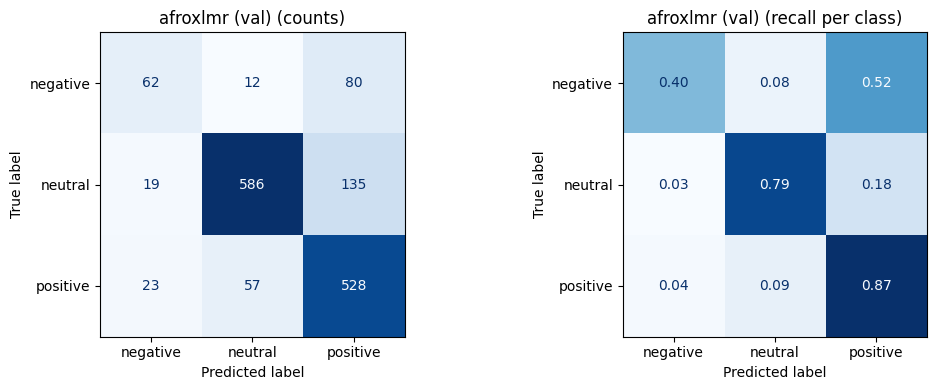

,tweet_id,text,true,predicted,agreement,confidence
278,YOOT7OJW,".MUMPS ND MEASLES SHOT, TETANUS SHOT, ND TB SK...",1,0,1.000000,0.9913
826,2IP605V9,Measles can spread further than thought on air...,1,0,0.666667,0.9899
1168,HG0NNSYZ,Hurt over measles lingers in small town: Four ...,1,0,0.666667,0.9869
661,WFTO3JZJ,The person who visited Super Bowl village with...,-1,0,0.333333,0.9869
608,DVMK1WEI,"""<user> RT <user> RT <user> For God's sake. Va...",-1,1,0.666667,0.9840
...,...,...,...,...,...,...
1438,UJF3FYZ8,A3441 [NEW] Eliminates use of vaccines contain...,0,-1,0.666667,0.4187
1315,EAIESSFT,<user> <user> 95% of kindergartners in 2009 we...,0,1,0.666667,0.4176
1433,EK3CX4V9,<user> New discovery found that inject measles...,-1,0,0.333333,0.3912
1212,LRU41ATU,<user> I can't remember? Did you think ur son...,0,1,0.666667,0.3606


In [15]:
from src.models.transformer import predict
from src.evaluate import plot_confusion_matrix, export_errors

y_pred2, confidence2 = predict(trainer2, tokenizer2, val_df)
plot_confusion_matrix(val_df["label"], y_pred2, "afroxlmr (val)", name="transformer_afroxlmr_val_cm")
export_errors(val_df, y_pred2, confidence2, exp_id="T2")

In [16]:
from src.utils import add_takeaway

add_takeaway("T1", "twitter-roberta is the stronger model overall: 0.52 recall on negative and 0.82 on neutral, both noticeably "
                   "higher than afroxlmr's 0.40 and 0.79. Its main confusion is negative tweets being misread as positive (45 cases) "
                   "and neutral tweets pulled toward positive (112 cases) - both consistent with sarcasm or mixed-sentiment tweets "
                   "being read at face value rather than negative.")

add_takeaway("T2", "afroxlmr underperforms twitter-roberta on negative (0.40 vs 0.52) and neutral (0.79 vs 0.82) recall, despite "
                   "being pretrained on African languages including Swahili. This suggests the dataset's tweets are mostly English, "
                   "so twitter-roberta's Twitter-specific pretraining (slang, hashtags, informal grammar) matters more here than "
                   "afroxlmr's multilingual coverage. Its one strength is positive recall (0.87 vs 0.86), and like twitter-roberta "
                   "its biggest failure mode is negative tweets misread as positive (80 of 154 negative cases).")